In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(12046)

D:\conda\envs\timing_algorithm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 一些超参数
learning_rate = 1e-3
eval_iters = 10
batch_size = 1000
sequence_len = 64
# 如果有GPU，该脚本将使用GPU进行计算
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
raw_datasets = load_dataset('code_search_net', 'python_data')
datasets = raw_datasets['train'].filter(lambda x: 'apache/spark' in x['repository_name'])

In [6]:
class char_tokenizer(object):
    def __init__(self, data):
        # 数据中出现的所有字符构成字典
        chars = sorted(list(set(''.join(data))))
        # 预留一个位置给结尾的特殊字符
        self.char2ind = {s: i + 1 for i, s in enumerate(chars)}
        self.char2ind['<|e|>'] = 0
        self.ind2char = {i: s for s, i in self.char2ind.items()}

    def encode(self, text):
        return [self.char2ind[c] for c in text]

    def decode(self,enc):
        if isinstance(enc, int):
            return self.ind2char[enc]
        return [self.ind2char[i] for i in enc]

tok = char_tokenizer(datasets['whole_func_string'])
len(tok.char2ind)

98

In [8]:
class RNN(nn.Module):
    def __init__(self,input_size,hidden_size):
        """
        循环神经网络的神经元（支持批量计算）
        参数
        ---
        input_size:int，输入数据的特征长度
        hidden_size:int,隐藏状态的特征长度
        """
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h=nn.Linear(input_size+hidden_size,hidden_size)

    def forward(self,x,hidden=None):
        '''
        向前传播
        参数
        ---
        x:torch.Tensor输入数据的集合，形状为(B,T,C),其中B表示批量大小，T表示文本长度，C表示文本特征的长度(input_size)
        hidden:torch.FloatTensor 初始的隐藏状态，形状为(B,H),其中H表示隐藏状态的长度(hidden_size)
        返回
        ---
        hidden:torch.FloatTensor,所有隐藏状态的集合，形状为(B,T,H)
        '''
        re=[]
        B,T,C=x.shape
        x=x.transpose(0,1) # (T,B,C)
        if hidden is None:
            hidden=self.init_hidden(B,x.device)
        for i in range(T):
            # x[i]的形状是(B,C)；hidden的形状为(B,H)
            combined=torch.cat((x[i],hidden),dim=1) # (B,C+H)
            hidden=F.relu(self.i2h(combined))  #(   B,H)
            re.append(hidden)
        result_tensor=torch.stack(re,dim=0)  # (T,B,H)
        return result_tensor.transpose(0,1)  # (B,T,H)

    def init_hidden(self,B,device):
        # 默认的初始隐藏状态全部等于0
        return torch.zeros((B,self.hidden_size),device=device)


class CharRNNBatch(nn.Module):

    def __init__(self,vs):
        '''
        双层的循环神经网络(支持批量计算)
        参数
        ---
        vs:int,字典大小
        '''
        super(CharRNNBatch, self).__init__()
        # 定义文字嵌入的特征长度
        self.emb_size=256
        # 定义隐藏状态的特征长度
        self.hidden_size=128
        # 文字嵌入层
        self.embedding=nn.Embedding(vs,self.emb_size)
        # 随机失活
        self.dp=nn.Dropout(0.4)
        # 第一层的循环神经网络
        self.rnn1=RNN(self.emb_size,self.hidden_size)
        # 第二层的循环神经网络
        self.rnn2=RNN(self.hidden_size,self.hidden_size)
        # 语言建模头，根据隐藏状态预测下一个字母是什么
        self.h2o=nn.Linear(self.hidden_size,vs)

    def forward(self,x):
        '''
        向前传播
        参数
        ---
        x:torch.LongTensor,当前字母在字典中的位置，形状为(B,T)
        返回
        ---
        output:torch.LongTensor,预测结果的logits，形状为(B,T,vs)
        '''
        emb=self.embedding(x)  # (B,T,C)
        h=self.dp(self.rnn1(emb))  #(B,T,H)
        # 第一层的隐藏状态是第二层的输入
        h=self.dp(self.rnn2(h))  # (B,T,H)
        # 使用第二层的隐藏状态预测下一个字母是什么
        output=self.h2o(h)  # (B,T,vs)
        return output

model = CharRNNBatch(len(tok.char2ind)).to(device)

In [9]:
# 展示模型结构
model

CharRNNBatch(
  (embedding): Embedding(98, 256)
  (dp): Dropout(p=0.4, inplace=False)
  (rnn1): RNN(
    (i2h): Linear(in_features=384, out_features=128, bias=True)
  )
  (rnn2): RNN(
    (i2h): Linear(in_features=256, out_features=128, bias=True)
  )
  (h2o): Linear(in_features=128, out_features=98, bias=True)
)

In [10]:
@torch.no_grad()
def generate_batch(model, idx, max_new_tokens=300):
    '''
    利用模型生成文本（反复使用模型进行预测）
    参数
    ----
    model ：CharRNNBatch，生成文本的模型
    idx ：torch.LongTensor，当前字母在字典中的位置，形状为(1, T)
    max_new_tokens ：int，生成文本的最大长度
    返回
    ----
    out ：list[int]，生成的文本
    '''
    # 将模型切换至评估模式
    model.eval()
    for _ in range(max_new_tokens):
        # 限制北京长度，使之与模型训练时的状况更相符
        # 当然也可以不限制
        context=idx[:,-sequence_len:]
        # 在文本生成时，模型的计算效率很低，因为有很多重复计算
        logits=model(context)
        # 只使用最后一个预测结果
        logits=logits[:,-1,:]
        probs=F.softmax(logits, dim=-1)
        # 根据模型预测的概率，得到最终的预测结果(下一个字母)
        # 这一步运算有一定随机性
        ix=torch.multinomial(probs, num_samples=1)
        idx=torch.cat((idx,ix),dim=1)
        if ix.item()==0:
            break
    # 将模型切换至训练模式
    model.train()
    return idx.tolist()[0]

In [11]:
# 使用模型来生成文本
begin_text = torch.tensor(tok.encode('def'), device=device).unsqueeze(0)
print(''.join(tok.decode(generate_batch(model, begin_text))))

defJjWRUm*&6]RGRörD'})_\XjXUL6m)}ö2D[A",G?7u^QVH[yg\,=f_%Sy''zw^Hb]*4i[<|e|>


In [15]:
def process(data, sequence_len=sequence_len):
    '''
    根据文本生成训练数据
    '''
    # text是字符串列表
    text = data['whole_func_string']
    inputs, labels = [], []
    for i in text:
        enc = tok.encode(i)
        # 0对应着文本结束
        enc += [0]
        # 将文本转换为多个训练数据
        for i in range(len(enc) - sequence_len):
            inputs.append(enc[i: i + sequence_len])
            # 预测标签是下一个字母，因此只需要挪动一个位置即可
            labels.append(enc[i + 1: i + 1 + sequence_len])
    return {'inputs': inputs, 'labels': labels}

# 将数据分为训练集和测试集
tokenized = datasets.train_test_split(test_size=0.1, seed=1024, shuffle=True)
# 将文本转换为训练数据，里面包含inputs和labels
tokenized = tokenized.map(process, batched=True, remove_columns=datasets.column_names)
tokenized.set_format(type='torch', device=device)

tokenized['train']['inputs'].shape, tokenized['train']['labels'].shape

Map: 100%|██████████| 69/69 [00:02<00:00, 32.62 examples/s]


(torch.Size([605913, 64]), torch.Size([605913, 64]))

In [16]:
# 构建数据读取器
train_loader = DataLoader(tokenized['train'], batch_size=batch_size, shuffle=True)
test_loader = DataLoader(tokenized['test'], batch_size=batch_size, shuffle=True)
# 获取一个批量的数据
next(iter(test_loader))

{'inputs': tensor([[71, 90, 10,  ..., 81, 79, 82],
         [80, 10, 86,  ..., 31,  2, 86],
         [20, 11, 28,  ...,  2, 31,  2],
         ...,
         [67, 78, 80,  ...,  1,  2,  2],
         [86, 71, 38,  ...,  9, 11, 11],
         [ 2,  2,  2,  ..., 40, 84, 67]]),
 'labels': tensor([[90, 10, 72,  ..., 79, 82, 84],
         [10, 86, 68,  ...,  2, 86, 68],
         [11, 28,  1,  ..., 31,  2, 72],
         ...,
         [78, 80, 67,  ...,  2,  2,  2],
         [71, 38, 67,  ..., 11, 11, 16],
         [ 2,  2, 28,  ..., 84, 67, 79]])}

In [19]:
def estimate_loss(model):
    re = {}
    # 将模型切换至评估模式
    model.eval()
    re['train'] = _loss(model, train_loader)
    re['test'] = _loss(model, test_loader)
    # 将模型切换至训练模式
    model.train()
    return re

@torch.no_grad()
def _loss(model, data_loader):
    """
    计算模型在不同数据集下面的评估指标
    """
    loss = []
    data_iter= iter(data_loader)
    # 随机使用多个批量数据来预估模型效果
    for k in range(eval_iters):
        data = next(data_iter, None)
        if data is None:
            data_iter = iter(data_loader)
            data = next(data_iter, None)
        inputs, labels = data['inputs'], data['labels']
        logits = model(inputs)
        # 根据cross_entropy的定义，需要对logits进行转置运算
        # 具体细节请参考cross_entropy的官方文档
        logits = logits.transpose(-2, -1)
        loss.append(F.cross_entropy(logits, labels).item())
    return torch.tensor(loss).mean().item()

estimate_loss(model)

{'train': 4.572457790374756, 'test': 4.573501110076904}

In [20]:
def train_rnn(model, optimizer, data_loader, epochs=10):
    lossi = []
    for epoch in range(epochs):
        for i, data in enumerate(data_loader, 0):
            inputs, labels = data['inputs'], data['labels']
            optimizer.zero_grad()
            logits = model(inputs)
            # 根据cross_entropy的定义，需要对logits进行转置运算
            # 具体细节请参考cross_entropy的官方文档
            logits = logits.transpose(-2, -1)
            loss = F.cross_entropy(logits, labels)
            lossi.append(loss.item())
            loss.backward()
            optimizer.step()
        # 评估模型，并输出结果
        stats = estimate_loss(model)
        train_loss = f'train loss {stats["train"]:.4f}'
        test_loss = f'test loss {stats["test"]:.4f}'
        print(f'epoch {epoch:>2}: {train_loss}, {test_loss}')
    return lossi

In [27]:
l = train_rnn(model, optim.Adam(model.parameters(), lr=learning_rate), train_loader,epochs=2)

KeyboardInterrupt: 

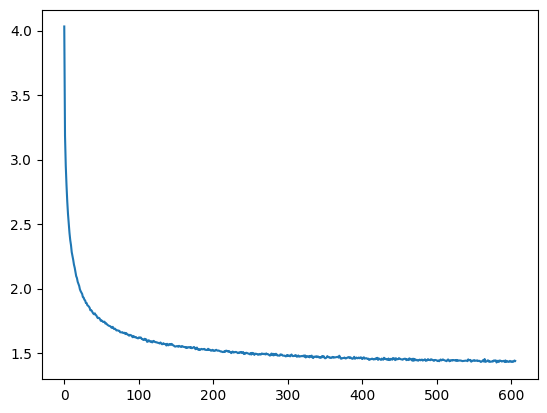

In [22]:
plt.plot(torch.tensor(l).view(-1, 10).mean(1).numpy())

In [26]:
# 使用模型来生成文本
begin_text = torch.tensor(tok.encode('def'), device=device).unsqueeze(0)
print(''.join(tok.decode(generate_batch(model, begin_text))))

def watten file
            boon.moded this melinall :class:``ser1 (0():
            :param rows, jsty) This Bition a range the defould.

        :param func.= p{->)
                                   seaf column:
        """
        in moxumisg to RDD is sign, -1:Se expal.                          The
